# BITS NuPlan Reproduction Demo

This advanced example loads saved BITS artifacts, runs real NuPlan samples through the torch inference stack, inspects intermediate plan and prediction tensors, scores candidate trajectories, and reads saved evaluation summaries.

This is a reproduction notebook rather than the public behavior-model quickstart. The public user path is shown in `bits_behavior_model_demo.ipynb`; training and cache rebuilding are handled by `scripts/run_bits_planner_cached_train.py`.


## 1. Reproduction Inputs

Required inputs:

1. NuPlan data and map files;
2. a JSON `BitsRunConfig` describing the train/validation/test logs;
3. torch dependencies installed with `pip install -e .[bits]`;
4. a Tactics2D planner checkpoint, an official or local predictor checkpoint, or both.

Typical commands:

```bash
python scripts/run_bits_planner_cached_train.py   --config path/to/bits_run_config.json   --output-dir path/to/output   --cache-dir path/to/cache   --predictor-checkpoint path/to/predictor.ckpt   --build-cache-only

python scripts/run_bits_planner_cached_train.py   --config path/to/bits_run_config.json   --output-dir path/to/output   --cache-dir path/to/cache   --predictor-checkpoint path/to/predictor.ckpt   --epochs 120   --batch-size 1   --final-eval

python scripts/run_bits_planner_cached_train.py   --config path/to/bits_run_config.json   --output-dir path/to/new_output   --cache-dir path/to/cache   --warm-start path/to/bits_planner_best_val.pt   --predictor-checkpoint path/to/predictor.ckpt   --reuse-cache   --epochs 20
```


In [15]:
from pathlib import Path
import json
import os
import sys
import warnings

import numpy as np


def find_repo_root(start):
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tactics2d" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Cannot find the Tactics2D repository root.")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

warnings.filterwarnings("ignore", message="Trying to unpickle estimator SVC.*")

from tactics2d.behavior.bits.model import BitsAgentPrediction, BitsPlan, BitsPlanScorer
from tactics2d.behavior.bits.training import (
    build_nuplan_bits_dataset,
    load_bits_inference_model,
    load_bits_run_config,
    run_nuplan_bits_open_loop_protocol,
    run_nuplan_bits_rolling_protocol,
)
from tactics2d.behavior.bits.torch_model import bits_batch_to_torch
from tactics2d.dataset_parser import NuPlanParser

try:
    import torch
except ImportError:
    torch = None

CHECKPOINT_ROOT = Path(
    os.environ.get("TACTICS2D_BITS_CHECKPOINT_ROOT", "D:/tactics/checkpoints/bits")
).expanduser()
RUN_ROOT = CHECKPOINT_ROOT / "nuplan_mini_all_unet_v1"
TRAIN_RUN_DIR = RUN_ROOT / "train_valid57_4sample_clean_decoder_e120"
PLANNER_DIR = TRAIN_RUN_DIR / "planner_frozen_predictor"
RUN_CONFIG_PATH = PLANNER_DIR / "bits_run_config.json"
PLANNER_CHECKPOINT = PLANNER_DIR / "bits_planner_best_val.pt"
PREDICTOR_CHECKPOINT = (
    CHECKPOINT_ROOT
    / "nusc_dynUnicycle_gl0_yrl0_tfTrue_4130553"
    / "run0"
    / "checkpoints"
    / "iter94000_ep6_valLoss0.06.ckpt"
)
OPEN_LOOP_DIR = PLANNER_DIR
ROLLING_DIR = TRAIN_RUN_DIR / "rolling_clean_decoder_eval"
OPEN_LOOP_RESULT_PATH = OPEN_LOOP_DIR / "bits_planner_cached_train_result.json"
ROLLING_RESULT_PATH = ROLLING_DIR / "bits_rolling_protocol_result.json"

RUN_EVALUATION = False
DEMO_SPLIT_NAME = "train"
DEMO_LOG_INDEX = 2
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

print("repo_root:", repo_root)
print("device:", DEVICE)


repo_root: D:\tactics\tactics2d
device: cuda


## 2. Load Run Configuration And Checkpoints

The selected local run uses a planner checkpoint trained on the usable NuPlan mini logs and a predictor checkpoint for the low-level policy and neighboring-agent future head.


In [16]:
if torch is None:
    raise ImportError("torch is required for BITS reproduction. Install tactics2d[bits].")

required_paths = {
    "run_config": RUN_CONFIG_PATH,
    "planner_checkpoint": PLANNER_CHECKPOINT,
    "predictor_checkpoint": PREDICTOR_CHECKPOINT,
}
for name, path in required_paths.items():
    print(f"{name}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

run_config = load_bits_run_config(RUN_CONFIG_PATH)
split_sizes = {
    "train": len(run_config.split.train),
    "val": len(run_config.split.val),
    "test": len(run_config.split.test),
}
checkpoint_metadata = torch.load(PLANNER_CHECKPOINT, map_location="cpu").get("metadata", {})

print("split sizes:", split_sizes)
print("schedule:", run_config.schedule)
print("config future/history:", run_config.config.future_steps, run_config.config.history_steps)
print("selected planner epoch:", checkpoint_metadata.get("epoch", "unknown"))


run_config: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_run_config.json
planner_checkpoint: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_planner_best_val.pt
predictor_checkpoint: D:\tactics\checkpoints\bits\nusc_dynUnicycle_gl0_yrl0_tfTrue_4130553\run0\checkpoints\iter94000_ep6_valLoss0.06.ckpt
split sizes: {'train': 57, 'val': 8, 'test': 8}
schedule: BitsTrainingSchedule(epochs=120, batch_size=4, learning_rate=0.0001, weight_decay=0.0, hidden_dim=128, model_arch='resnet18', context_size=30, roi_feature_size=7, roi_layer_key='layer2', history_conditioning=True, use_transformer=True, use_ground_truth_goal=True, num_samples=None, mask_drivable=False, max_train_samples_per_log=4, max_val_samples_per_log=1, checkpoint_every_epochs=1, seed=47)
config future/history: 20 10
selected planner epoch: 120


## 3. Build Real NuPlan Samples

This parses one sample from each split using the saved run config. The visual demo uses a moving training sample so the candidate trajectories and selected future are easy to compare.


In [17]:
parser = NuPlanParser()
sample_cache = {}

for split_name in ("train", "val", "test"):
    spec = run_config.split.logs(split_name)[0]
    dataset = build_nuplan_bits_dataset(
        spec,
        config=run_config.config,
        include_raster=True,
        parser=parser,
    )
    batch = dataset[0]
    sample_cache[split_name] = (dataset, batch)
    print(split_name)
    print("  samples:", len(dataset))
    print("  first frame:", dataset.frames()[0] if dataset.frames() else None)
    print("  ego ids:", dataset.ego_ids())
    print("  image:", batch.image.shape)
    print("  future:", batch.target_positions.shape)
    print("  agents future:", batch.all_other_agents_future_positions.shape)

# Use a moving ego sample for the architecture visualization.
demo_spec = run_config.split.logs(DEMO_SPLIT_NAME)[DEMO_LOG_INDEX]
demo_dataset = build_nuplan_bits_dataset(
    demo_spec,
    config=run_config.config,
    include_raster=True,
    parser=parser,
)
test_dataset, test_batch = demo_dataset, demo_dataset[0]
print("demo sample")
print("  split/index:", DEMO_SPLIT_NAME, DEMO_LOG_INDEX)
print("  log:", demo_spec.data_file)
print("  frame:", test_batch.frame)
print("  ego id:", test_batch.ego_id)
print("  gt final xy:", test_batch.target_positions[-1].round(3).tolist())
print("  gt displacement:", round(float(np.linalg.norm(test_batch.target_positions[-1])), 3))
print("  available future agents:", int(test_batch.all_other_agents_future_availability.any(axis=1).sum()))


train
  samples: 35
  first frame: 11427536950
  ego ids: [1028]
  image: (14, 224, 224)
  future: (20, 2)
  agents future: (20, 20, 2)
val
  samples: 74
  first frame: 23688859249
  ego ids: [100]
  image: (14, 224, 224)
  future: (20, 2)
  agents future: (20, 20, 2)
test
  samples: 74
  first frame: 23688859249
  ego ids: [100]
  image: (14, 224, 224)
  future: (20, 2)
  agents future: (20, 20, 2)
demo sample
  split/index: train 2
  log: mini/2021.05.12.23.36.44_veh-35_00152_00504.db
  frame: 11432432800
  ego id: 129
  gt final xy: [33.075, -0.025]
  gt displacement: 33.075
  available future agents: 5


## 4. Run Multi-Sample BITS Inference

This cell follows the BITS inference path: spatial goal sampling, goal-conditioned ego trajectory prediction, neighboring-agent future prediction, and score-based candidate selection.


In [18]:
NUM_GOAL_SAMPLES = 8

inference = load_bits_inference_model(
    tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
    predictor_checkpoint=PREDICTOR_CHECKPOINT,
    image_channels=run_config.config.history_steps + 4,
    future_steps=run_config.config.future_steps,
    hidden_dim=run_config.schedule.hidden_dim,
    model_arch=run_config.schedule.model_arch,
    context_size=run_config.schedule.context_size,
    roi_feature_size=run_config.schedule.roi_feature_size,
    roi_layer_key=run_config.schedule.roi_layer_key,
    history_conditioning=run_config.schedule.history_conditioning,
    use_transformer=run_config.schedule.use_transformer,
    config=run_config.config,
    map_location="cpu",
    strict=True,
)

model = inference.model.to(DEVICE).eval()
torch_batch = bits_batch_to_torch(test_batch, device=DEVICE, include_optional=True)
if run_config.schedule.seed is not None:
    torch.manual_seed(run_config.schedule.seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(run_config.schedule.seed)

with torch.no_grad():
    multi_output = model(
        torch_batch.tensors,
        num_samples=NUM_GOAL_SAMPLES,
        mask_drivable=True,
    )

plan = multi_output["plan"]
predictions = multi_output["predictions"]

goal_xy = plan["positions"][0].detach().cpu().numpy()
goal_yaw = plan["yaws"][0, :, 0].detach().cpu().numpy()
goal_score = plan["scores"][0].detach().cpu().numpy()
goal_log_likelihood = plan["log_likelihood"][0].detach().cpu().numpy()

ego_candidates_xy = predictions["positions"][0].detach().cpu().numpy()
ego_candidates_yaw = predictions["yaws"][0].detach().cpu().numpy()
ego_candidates_availability = predictions["availabilities"][0].detach().cpu().numpy()
agent_candidates_xy = predictions["agent_positions"][0].detach().cpu().numpy()
agent_candidates_yaw = predictions["agent_yaws"][0].detach().cpu().numpy()
agent_candidates_availability = predictions["agent_availabilities"][0].detach().cpu().numpy()
gt_xy = test_batch.target_positions

candidate_plan = BitsPlan(
    positions=ego_candidates_xy,
    yaws=ego_candidates_yaw,
    availabilities=ego_candidates_availability,
    scores=goal_log_likelihood,
)
agent_prediction = BitsAgentPrediction(
    positions=agent_candidates_xy,
    yaws=agent_candidates_yaw,
    availabilities=agent_candidates_availability,
)
score_breakdown = BitsPlanScorer(run_config.config).score_batch(
    test_batch,
    candidate_plan,
    agent_prediction=agent_prediction,
)
selected_index = int(score_breakdown.total.argmax())
selected_ego_xy = ego_candidates_xy[selected_index]
selected_goal_xy = goal_xy[selected_index]
selected_agent_xy = agent_candidates_xy[selected_index]
selected_agent_availability = agent_candidates_availability[selected_index]

print("inference source:", inference.source)
print("compatible:", inference.compatibility.is_compatible)
print("matched keys:", len(inference.compatibility.matched_keys))
print("missing keys:", len(inference.compatibility.missing_keys))
print("goal samples:", goal_xy.shape)
print("ego candidate trajectories:", ego_candidates_xy.shape)
print("agent future predictions:", agent_candidates_xy.shape)
print("selected candidate index:", selected_index)
print("selected goal xy ego:", selected_goal_xy.round(3).tolist())
print("selected ego final xy:", selected_ego_xy[-1].round(3).tolist())
print("gt final xy:", gt_xy[-1].round(3).tolist())
print("score total:", score_breakdown.total.round(3).tolist())


inference source: mixed
compatible: True
matched keys: 377
missing keys: 0
goal samples: (8, 2)
ego candidate trajectories: (8, 20, 2)
agent future predictions: (8, 20, 20, 2)
selected candidate index: 5
selected goal xy ego: [33.21799850463867, -0.12800000607967377]
selected ego final xy: [33.68199920654297, 0.0010000000474974513]
gt final xy: [33.075, -0.025]
score total: [25.541, 18.805, 13.652, 24.643, 25.541, 25.975, 25.975, 14.055]


## 5. Inspect The Prediction Stack

The figure overlays raster context, sampled goals, ego candidates, predicted neighboring agents, scorer totals, and the selected trajectory against ground truth.


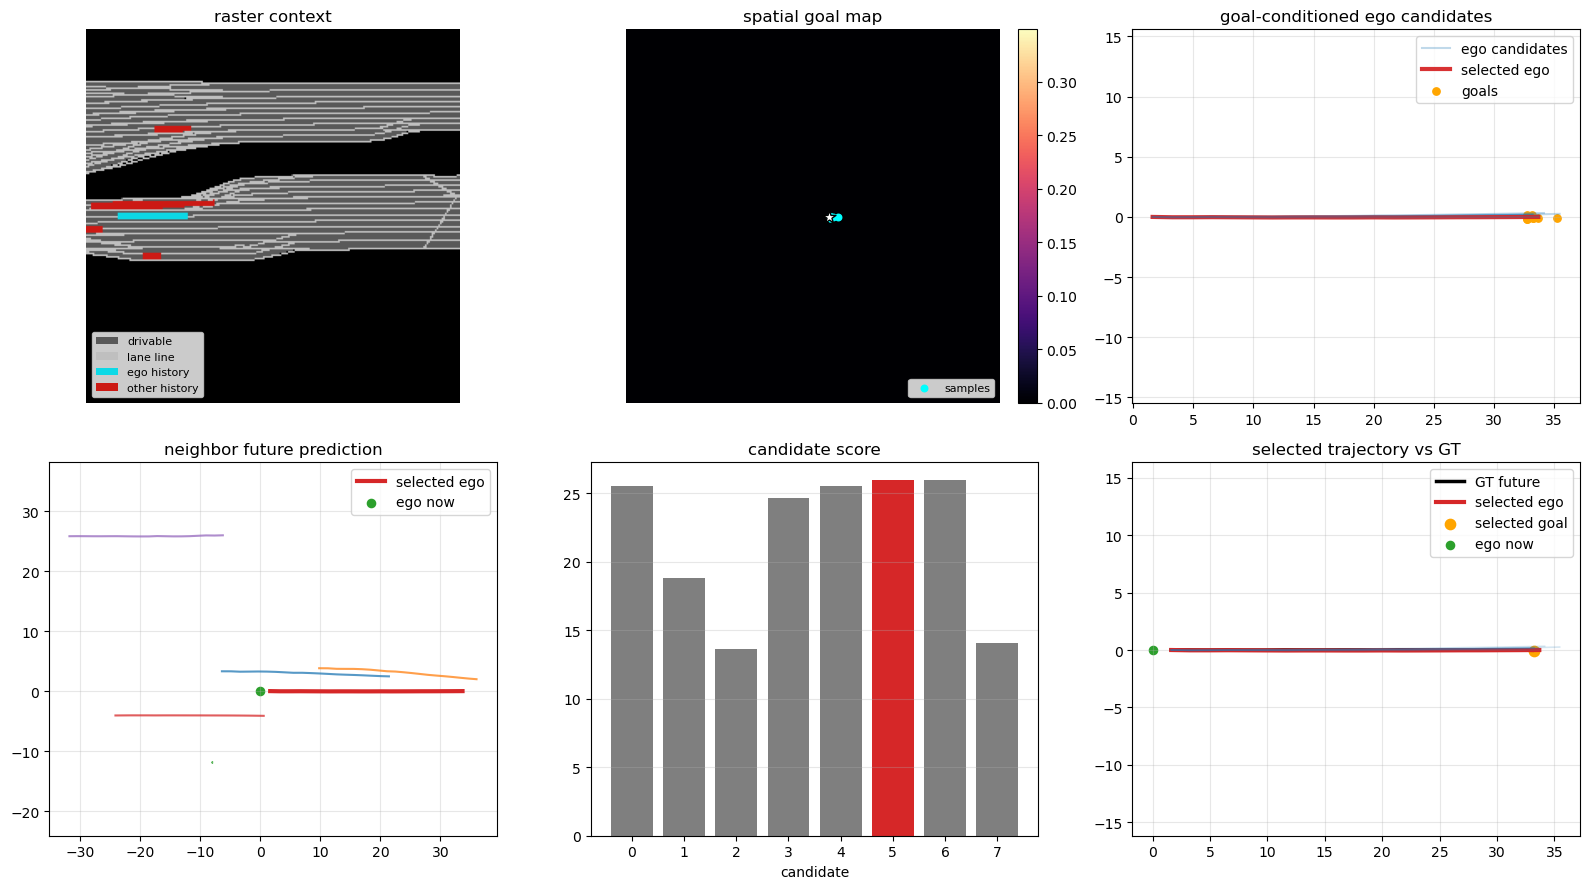

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

image = test_batch.image
history_channels = run_config.config.history_steps + 1
dynamic_channels = image[:history_channels]
ego_history_mask = np.any(dynamic_channels > 0, axis=0)
other_history_mask = np.any(dynamic_channels < 0, axis=0)
drivable = image[-3] > 0
lane_lines = image[-2] > 0
pedestrian = image[-1] > 0
preview = np.zeros((*drivable.shape, 3), dtype=float)
preview[drivable] = [0.35, 0.35, 0.35]
preview[lane_lines] = [0.75, 0.75, 0.75]
preview[pedestrian] = [0.45, 0.25, 0.55]
preview[other_history_mask] = [0.80, 0.10, 0.08]
preview[ego_history_mask] = [0.05, 0.85, 0.90]
prob_map = plan["location_prob_map"][0].detach().cpu().numpy()
argmax_row, argmax_col = np.unravel_index(np.argmax(prob_map), prob_map.shape)


def agent_to_raster(points):
    points = np.asarray(points, dtype=float)
    flat = points.reshape(-1, 2)
    hom = np.concatenate([flat, np.ones((flat.shape[0], 1))], axis=1)
    raster = hom @ test_batch.raster_from_agent.T
    return raster[:, :2].reshape(*points.shape)


raster_goal_xy = agent_to_raster(goal_xy)
available_agents = np.flatnonzero(selected_agent_availability.any(axis=1))
agent_indices_to_plot = available_agents[: min(8, available_agents.size)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(preview)
axes[0, 0].set_title("raster context")
axes[0, 0].axis("off")
axes[0, 0].legend(
    handles=[
        Patch(facecolor=(0.35, 0.35, 0.35), label="drivable"),
        Patch(facecolor=(0.75, 0.75, 0.75), label="lane line"),
        Patch(facecolor=(0.05, 0.85, 0.90), label="ego history"),
        Patch(facecolor=(0.80, 0.10, 0.08), label="other history"),
    ],
    loc="lower left",
    fontsize=8,
)

im = axes[0, 1].imshow(prob_map, cmap="magma")
axes[0, 1].scatter(raster_goal_xy[:, 0], raster_goal_xy[:, 1], c="cyan", s=22, label="samples")
axes[0, 1].scatter([argmax_col], [argmax_row], marker="*", c="white", s=95, edgecolors="black")
axes[0, 1].set_title("spatial goal map")
axes[0, 1].axis("off")
axes[0, 1].legend(loc="lower right", fontsize=8)
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

for index, trajectory in enumerate(ego_candidates_xy):
    selected = index == selected_index
    axes[0, 2].plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color="#d62728" if selected else "#1f77b4",
        alpha=0.95 if selected else 0.28,
        linewidth=3.0 if selected else 1.5,
        label="selected ego" if selected else ("ego candidates" if index == 0 else None),
    )
axes[0, 2].scatter(goal_xy[:, 0], goal_xy[:, 1], color="orange", s=28, label="goals")
axes[0, 2].set_title("goal-conditioned ego candidates")
axes[0, 2].axis("equal")
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend(loc="best")

for agent_index in agent_indices_to_plot:
    agent_traj = selected_agent_xy[agent_index]
    agent_avail = selected_agent_availability[agent_index]
    axes[1, 0].plot(agent_traj[agent_avail, 0], agent_traj[agent_avail, 1], linewidth=1.5, alpha=0.75)
axes[1, 0].plot(selected_ego_xy[:, 0], selected_ego_xy[:, 1], color="#d62728", linewidth=3, label="selected ego")
axes[1, 0].scatter([0], [0], color="#2ca02c", s=35, label="ego now")
axes[1, 0].set_title("neighbor future prediction")
axes[1, 0].axis("equal")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc="best")

x = np.arange(NUM_GOAL_SAMPLES)
axes[1, 1].bar(x, score_breakdown.total, color=["#d62728" if i == selected_index else "#7f7f7f" for i in x])
axes[1, 1].set_title("candidate score")
axes[1, 1].set_xlabel("candidate")
axes[1, 1].grid(True, axis="y", alpha=0.3)

axes[1, 2].plot(gt_xy[:, 0], gt_xy[:, 1], label="GT future", color="black", linewidth=2.5)
axes[1, 2].plot(selected_ego_xy[:, 0], selected_ego_xy[:, 1], label="selected ego", color="#d62728", linewidth=3)
for index, trajectory in enumerate(ego_candidates_xy):
    if index != selected_index:
        axes[1, 2].plot(trajectory[:, 0], trajectory[:, 1], color="#1f77b4", alpha=0.18, linewidth=1.2)
axes[1, 2].scatter([selected_goal_xy[0]], [selected_goal_xy[1]], label="selected goal", color="orange", s=55)
axes[1, 2].scatter([0], [0], label="ego now", color="#2ca02c", s=35)
axes[1, 2].set_title("selected trajectory vs GT")
axes[1, 2].axis("equal")
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(loc="best")

plt.tight_layout()


## 6. Open-Loop Evaluation

By default this reads the saved all-mini evaluation result. Set `RUN_EVALUATION = True` in the setup cell to rerun open-loop evaluation with the selected artifacts.


In [20]:
if RUN_EVALUATION:
    _model, open_loop_result = run_nuplan_bits_open_loop_protocol(
        run_config,
        OPEN_LOOP_DIR,
        tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
        predictor_checkpoint=PREDICTOR_CHECKPOINT,
        image_channels=run_config.config.history_steps + 4,
        future_steps=run_config.config.future_steps,
        hidden_dim=run_config.schedule.hidden_dim,
        model_arch=run_config.schedule.model_arch,
        context_size=run_config.schedule.context_size,
        roi_feature_size=run_config.schedule.roi_feature_size,
        roi_layer_key=run_config.schedule.roi_layer_key,
        history_conditioning=run_config.schedule.history_conditioning,
        use_transformer=run_config.schedule.use_transformer,
        strict=True,
    )
else:
    open_loop_result = None

if OPEN_LOOP_RESULT_PATH.exists():
    open_loop_payload = json.loads(OPEN_LOOP_RESULT_PATH.read_text(encoding="utf-8"))
    print("planner/open-loop result:", OPEN_LOOP_RESULT_PATH)
    if "inference" in open_loop_payload:
        print("source:", open_loop_payload["inference"]["source"])
        print("compatible:", open_loop_payload["inference"]["compatibility"]["is_compatible"])
        splits = ("train", "val", "test")
        for split_name in splits:
            result = open_loop_payload.get(split_name)
            if isinstance(result, list):
                result = result[0] if result else None
            if result is None:
                print(f"{split_name}: not evaluated in saved run")
            else:
                print(f"{split_name}: loss={result['mean_total_loss']:.4f}, samples={result['sample_count']}")
    else:
        for split_name in ("train", "val", "test"):
            result = open_loop_payload.get("eval", {}).get(split_name)
            if result is None:
                print(f"{split_name}: not evaluated in saved run")
            else:
                print(f"{split_name}: planner_loss={result['mean_total_loss']:.4f}, samples={result['sample_count']}")
else:
    print("open-loop result: not available")


planner/open-loop result: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\planner_frozen_predictor\bits_planner_cached_train_result.json
train: not evaluated in saved run
val: planner_loss=0.3471, samples=8
test: planner_loss=0.3471, samples=8


## 7. Closed-Loop Rolling Evaluation

This optional cell can run a short rolling rollout. The default notebook execution only reports whether a saved rolling result is available.


In [21]:
if RUN_EVALUATION:
    _model, rolling_result = run_nuplan_bits_rolling_protocol(
        run_config,
        ROLLING_DIR,
        tactics2d_planner_checkpoint=PLANNER_CHECKPOINT,
        predictor_checkpoint=PREDICTOR_CHECKPOINT,
        image_channels=run_config.config.history_steps + 4,
        future_steps=run_config.config.future_steps,
        hidden_dim=run_config.schedule.hidden_dim,
        model_arch=run_config.schedule.model_arch,
        context_size=run_config.schedule.context_size,
        roi_feature_size=run_config.schedule.roi_feature_size,
        roi_layer_key=run_config.schedule.roi_layer_key,
        history_conditioning=run_config.schedule.history_conditioning,
        use_transformer=run_config.schedule.use_transformer,
        split_name="test",
        simulation_steps=1,
        parser=NuPlanParser(),
        device=DEVICE,
        map_location="cpu",
        strict=True,
        num_samples=2,
        mask_drivable=True,
    )
else:
    rolling_result = None

if ROLLING_RESULT_PATH.exists():
    rolling_payload = json.loads(ROLLING_RESULT_PATH.read_text(encoding="utf-8"))
    summary = rolling_payload["test"]["summary"]
    print("rolling result:", ROLLING_RESULT_PATH)
    print("source:", rolling_payload["inference"]["source"])
    print("simulation steps:", rolling_payload["test"]["simulation_steps"])
    print("evaluated logs:", summary["evaluated_log_count"])
    print("skipped logs:", summary["skipped_log_count"])
    print("collisions:", summary["collision_count"])
    print("off-drivable:", summary["off_drivable_count"])
    print("mean off-drivable rate:", round(summary["mean_off_drivable_rate"], 4))
    print("controlled ADE:", round(summary["mean_controlled_ade"], 4))
    print("controlled FDE:", round(summary["mean_controlled_fde"], 4))
else:
    print("rolling result: not available")


rolling result: D:\tactics\checkpoints\bits\nuplan_mini_all_unet_v1\train_valid57_4sample_clean_decoder_e120\rolling_clean_decoder_eval\bits_rolling_protocol_result.json
source: mixed
simulation steps: 10
evaluated logs: 8
skipped logs: 0
collisions: 1
off-drivable: 105
mean off-drivable rate: 0.0774
controlled ADE: 0.0383
controlled FDE: 0.1137


## 8. Current Local Results

The saved planner checkpoint used by this inference demo is:

`D:/tactics/checkpoints/bits/nuplan_mini_all_unet_v1/train_valid57_4sample_clean_decoder_e120/planner_frozen_predictor/bits_planner_best_val.pt`

Saved run summary:

| protocol | result |
| --- | --- |
| split | train `57`, val `8`, test `8` usable logs |
| notebook mode | inference/demo only; no optimizer step is run here |
| saved training artifact | `213` cached train samples, `120` epochs, `6480` optimizer steps, final train loss `0.3854`, best/final val planner loss `0.3471` |
| training script | `scripts/run_bits_planner_cached_train.py` |
| notebook demo sample | `train[2]`, moving ego, GT displacement about `33 m`, `5` neighboring agents |
| notebook inference | `8` goal samples, `8` ego trajectory candidates, scorer-selected final trajectory |
| open-loop mixed | cached planner-only eval: val loss `0.3471`, test loss `0.3471` |
| rolling mixed | available only when the saved rolling result exists locally |

These numbers are local reproduction sanity checks, not a paper-level NuPlan benchmark.
